# Assignment 1 (20th March)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 1.1: Gradient Boosting Implementation(30 points)
Implement gradient boosting from scratch for regression:

• Use decision tree stumps as base learners.

• Implement learning rate and number of estimators as hyperparameters.

• Test on the California Housing dataset.

• Compare performance with scikit-learn’s GradientBoostingRegressor.

In [1]:
import numpy as np  # array manipulation and mathematical operations
import pandas as pd  # data manipulation and analysis
from sklearn.ensemble import GradientBoostingRegressor  # Scikit-learn's implementation of Gradient Boosting for regression tasks
from sklearn.tree import DecisionTreeRegressor  # For tree stump base estimator in Gradient Boosting
from sklearn.datasets import fetch_california_housing  # To load the California housing dataset
import matplotlib.pyplot as plt  # For plotting feature importance and cross-validation results

In [2]:
np.random.seed(123)  # Set a random seed for reproducibility

### The algorithm 
Prediction of the first $m$ base learners is given by the following formula:
$$ F_m(x) = F_{m-1}(x) + \eta \gamma_mh_m(x),$$
where $\eta$ is the learning rate and $\gamma_m$ is the optimal step size for the $m-th$ base learner $h_m(x)$.
In order to compute the optimal step size $\gamma_m$ for the $m-th$ base learner, we need to minimize the loss function with respect to $\gamma$. 

The general formula for $\gamma_m$ with loss function MSE is
$$\gamma_m = \underset{\gamma}{\operatorname{arg\,min}} \frac{1}{2}\sum_{i=1}^n(y_i - F_{m-1}(x_i) - \gamma h_m(x_i))^2.$$

By differentiation with respect to $\gamma$ we find the minnima as follows:
$$\gamma_m = \frac{\sum_{i=1}^n(y_i - F_{m-1}(x_i))h_m(x_i)}{\sum_{i=1}^nh_m(x_i)}.$$





In [3]:
class GB:
    """Custom implementation of Gradient Boosting Regressor using decision tree stumps as base learners."""
    def __init__(self, n_estimators=100, learning_rate=0.1, compute_optimal_step_size=False):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.compute_optimal_step_size = compute_optimal_step_size
        self.init_prediction = 0.0
        self.stumps = []
        self.step_sizes = []

    def _compute_optimal_step_size(self, y_true, y_pred, update):
        residuals = y_true - y_pred
        numerator = np.sum(residuals * update)
        denominator = np.sum(update ** 2)
        if denominator <= 1e-12:
            return 0.0
        return float(numerator / denominator)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.init_prediction = float(y.mean())
        y_pred = np.full(y.shape, self.init_prediction, dtype=float)
        self.stumps = []
        self.step_sizes = []  # gammas for each stump

        for _ in range(self.n_estimators):
            residuals = y - y_pred
            stump = DecisionTreeRegressor(max_depth=1)
            stump.fit(X, residuals)
            update = stump.predict(X)

            if self.compute_optimal_step_size:
                gamma = self._compute_optimal_step_size(y_true=y, y_pred=y_pred, update=update)
            else:
                gamma = 1.0

            y_pred += self.learning_rate * gamma * update
            self.stumps.append(stump)
            self.step_sizes.append(gamma)

        return self

    def predict(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        y_pred = np.full(X.shape[0], self.init_prediction, dtype=float)
        for stump, gamma in zip(self.stumps, self.step_sizes):
            y_pred += self.learning_rate * gamma * stump.predict(X)
        return y_pred

### The data (california housing dataset)

Here the aim is to predict the median house value in California districts based on various features such as median income, average house age, and proximity to the ocean. The dataset contains 20,640 samples with 8 features each, and the target variable is the median house value.


In [4]:
import ssl, certifi # Ensure that SSL certificates are properly handled for secure connections 
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

# fetch the california housing dataset
data = fetch_california_housing()
X = data.data
y = data.target
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### EDA

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
First 5 rows of data:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]
First 5 target values:
 [4.526 3.585 3.521 3.413 3.422]
Missing values in features: 0
Missing values in target: 0


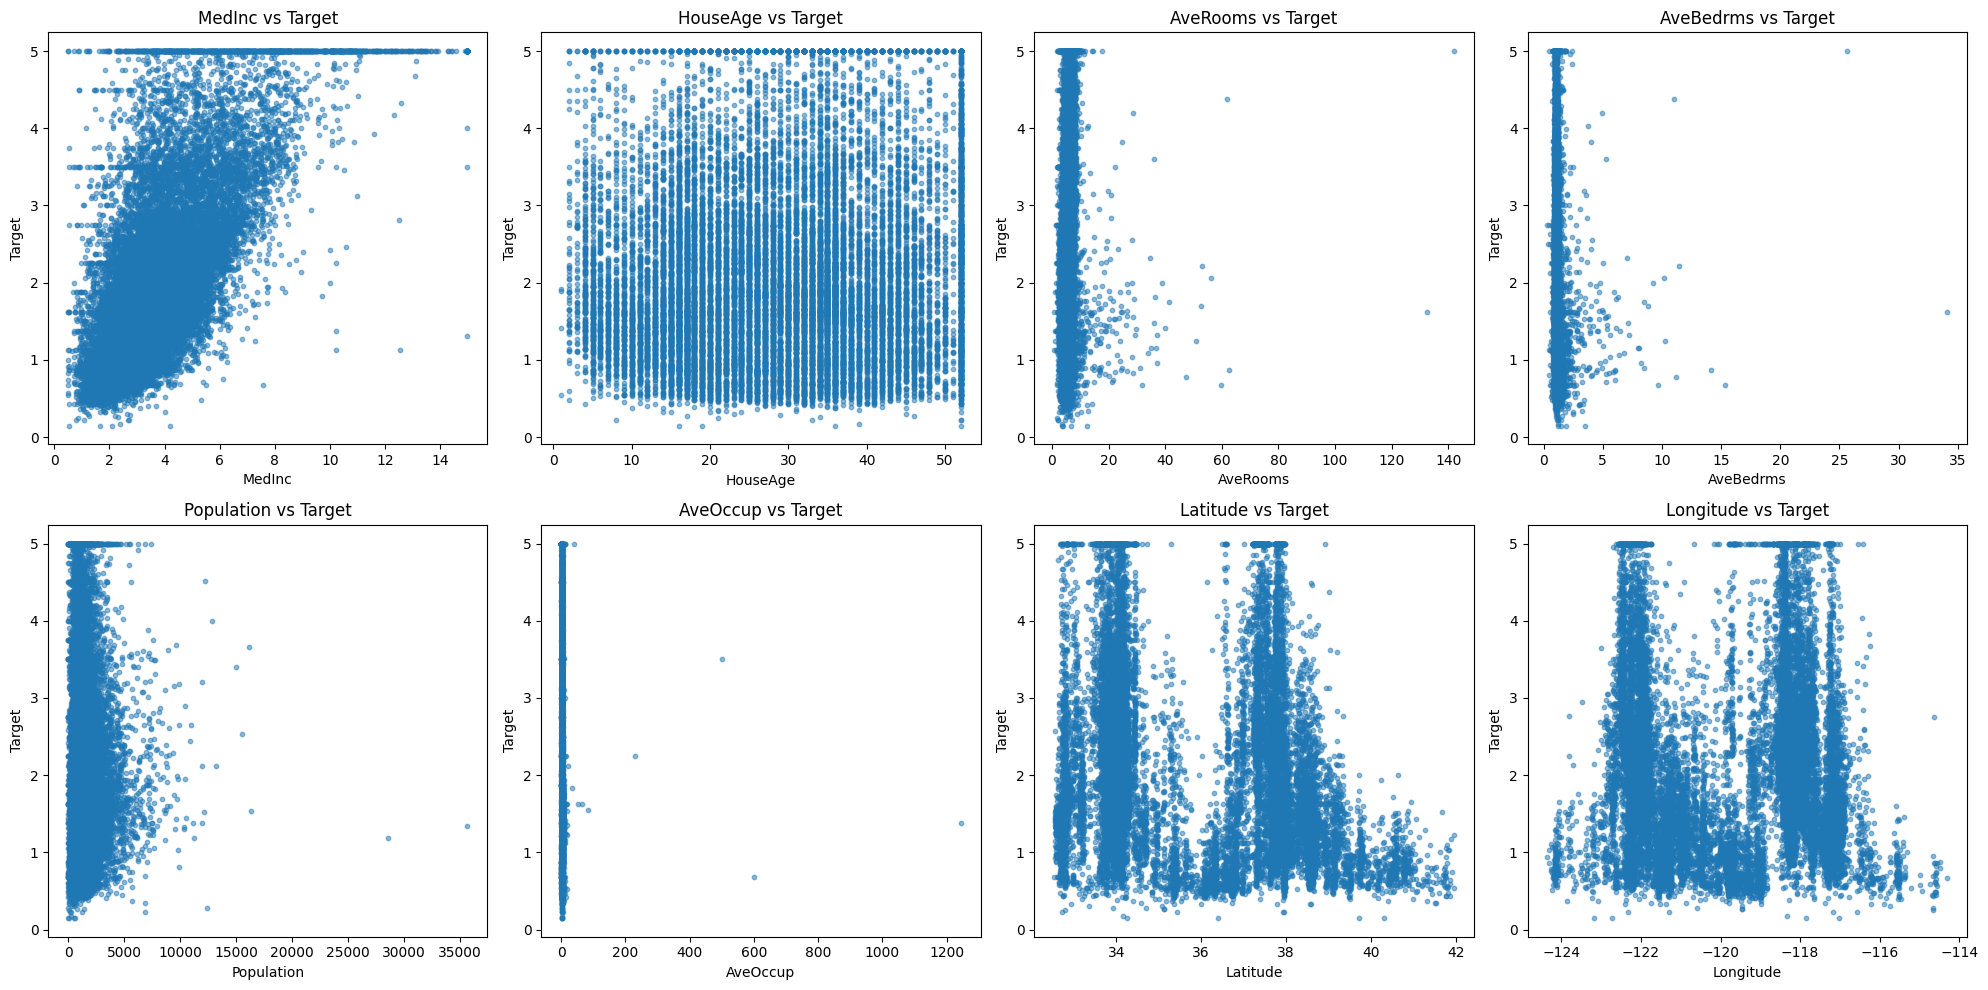

In [5]:
print("Feature names:", data.feature_names)
print("First 5 rows of data:\n", X[:5])
print("First 5 target values:\n", y[:5])
print("Missing values in features:", np.isnan(X).sum())
print("Missing values in target:", np.isnan(y).sum())

# some plots to understand the data better
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, ax in enumerate(axes.flatten()):
    ax.scatter(X[:, i], y, alpha=0.5, s=10)
    ax.set_xlabel(data.feature_names[i])
    ax.set_ylabel("Target")
    ax.set_title(f"{data.feature_names[i]} vs Target")
plt.tight_layout()
plt.show()


The most important feature is the median income, which has a strong positive correlation with the target variable (median house value). This feature will most likely be used as the split point in the first few iterations of the gradient boosting algorithm, as it provides the most significant reduction in the loss function. 

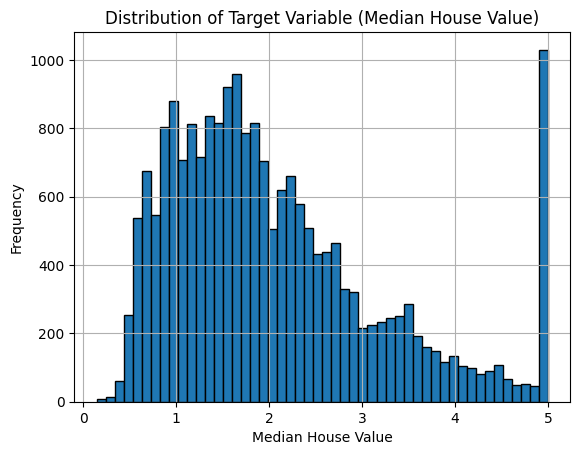

In [6]:
plt.hist(y, bins=50, edgecolor='k')
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable (Median House Value)")
plt.grid(True)
plt.show()

The distribution of the target variable is right-skewed, with a long tail towards higher values, indicating that there are some districts with very high median house values compared to the majority of the data. 

### Sklearn comparison

In [7]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_builders = {
    "sklearn GBR": lambda: GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.01, max_depth=1, random_state=42
    ),
    "Our GB (gamma=1)": lambda: GB(
        n_estimators=100, learning_rate=0.01, compute_optimal_step_size=False
    ),
    "Our GB (optimal gamma)": lambda: GB(
        n_estimators=100, learning_rate=0.01, compute_optimal_step_size=True
    ),
}

results = []
for model_name, build_model in model_builders.items():
    fold_r2, fold_mae, fold_rmse = [], [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_model()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_r2.append(r2_score(y_test, y_pred))
        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(root_mean_squared_error(y_test, y_pred))

    results.append({
        "Model": model_name,
        "R2_mean": np.mean(fold_r2),
        "R2_std": np.std(fold_r2),
        "MAE_mean": np.mean(fold_mae),
        "MAE_std": np.std(fold_mae),
        "RMSE_mean": np.mean(fold_rmse),
        "RMSE_std": np.std(fold_rmse),
    })

cv_results_df = pd.DataFrame(results).sort_values("R2_mean", ascending=False).reset_index(drop=True)
cv_results_df

,Model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,Our GB (gamma=1),0.322381,0.007069,0.738601,0.005253,0.94973,0.007659
1,sklearn GBR,0.322381,0.007069,0.738601,0.005253,0.94973,0.007659
2,Our GB (optimal gamma),0.322381,0.007069,0.738601,0.005253,0.94973,0.007659


Results of the comparison between our implementation and sklearn's GradientBoostingRegressor show that both models perform similarly in terms of R2 score, MAE, and RMSE. This is due to the fact that both models use tree stumps as base learners and are trained on the same dataset with the same hyperparameters (learning rate and number of estimators).

## Problem 1.2: XGBoost vs. LightGBM vs. CatBoost (25 points)
Compare the three leading gradient boosting implementations:

• Use the Kaggle House Prices dataset.

• Evaluate training time, memory usage, and predictive performance.

• Analyze feature importance from each model.

• Discuss strengths and weaknesses of each approach.

In [8]:
import xgboost as xgb  # for XGBoost implementation
import lightgbm as lgb # for LightGBM implementation
import catboost as cb  # for CatBoost implementation
import tracemalloc  # For measuring memory usage
import time  # For measuring training time
from sklearn.model_selection import train_test_split # For splitting the dataset into training and testing sets
import pandas as pd  # data manipulation and analysis
import matplotlib.pyplot as plt  # For plotting feature importance and cross-validation results
import numpy as np  # array manipulation and mathematical operations
from sklearn.model_selection import RepeatedKFold # For performing repeated K-Fold cross-validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # For evaluating model performance

In [9]:
data = pd.read_csv('data/house_prices.csv', index_col=0)

print("Dataset shape:", data.shape)

Dataset shape: (1460, 80)


### Dataset Features Description

**Target Variable:**
- **SalePrice**: The property's sale price in dollars

**Property Basics:**
- **MSSubClass**: The building class
- **MSZoning**: The general zoning classification
- **LotFrontage**: Linear feet of street connected to property
- **LotArea**: Lot size in square feet
- **Street**: Type of road access
- **Alley**: Type of alley access
- **LotShape**: General shape of property
- **LandContour**: Flatness of the property
- **Utilities**: Type of utilities available
- **LotConfig**: Lot configuration
- **LandSlope**: Slope of property

**Location & Proximity:**
- **Neighborhood**: Physical locations within Ames city limits
- **Condition1**: Proximity to main road or railroad
- **Condition2**: Proximity to main road or railroad (if a second is present)

**Building Information:**
- **BldgType**: Type of dwelling
- **HouseStyle**: Style of dwelling
- **OverallQual**: Overall material and finish quality
- **OverallCond**: Overall condition rating
- **YearBuilt**: Original construction date
- **YearRemodAdd**: Remodel date

**Exterior Features:**
- **RoofStyle**: Type of roof
- **RoofMatl**: Roof material
- **Exterior1st**: Exterior covering on house
- **Exterior2nd**: Exterior covering on house (if more than one material)
- **MasVnrType**: Masonry veneer type
- **MasVnrArea**: Masonry veneer area in square feet
- **ExterQual**: Exterior material quality
- **ExterCond**: Present condition of the material on the exterior

**Foundation & Basement:**
- **Foundation**: Type of foundation
- **BsmtQual**: Height of the basement
- **BsmtCond**: General condition of the basement
- **BsmtExposure**: Walkout or garden level basement walls
- **BsmtFinType1**: Quality of basement finished area
- **BsmtFinSF1**: Type 1 finished square feet
- **BsmtFinType2**: Quality of second finished area (if present)
- **BsmtFinSF2**: Type 2 finished square feet
- **BsmtUnfSF**: Unfinished square feet of basement area
- **TotalBsmtSF**: Total square feet of basement area

**Heating & Utilities:**
- **Heating**: Type of heating
- **HeatingQC**: Heating quality and condition
- **CentralAir**: Central air conditioning
- **Electrical**: Electrical system

**Living Areas:**
- **1stFlrSF**: First Floor square feet
- **2ndFlrSF**: Second floor square feet
- **LowQualFinSF**: Low quality finished square feet (all floors)
- **GrLivArea**: Above grade (ground) living area square feet

**Bathrooms & Bedrooms:**
- **BsmtFullBath**: Basement full bathrooms
- **BsmtHalfBath**: Basement half bathrooms
- **FullBath**: Full bathrooms above grade
- **HalfBath**: Half baths above grade
- **Bedroom**: Number of bedrooms above basement level
- **Kitchen**: Number of kitchens
- **KitchenQual**: Kitchen quality
- **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms)
- **Functional**: Home functionality rating

**Garage:**
- **GarageType**: Garage location
- **GarageYrBlt**: Year garage was built
- **GarageFinish**: Interior finish of the garage
- **GarageCars**: Size of garage in car capacity
- **GarageArea**: Size of garage in square feet
- **GarageQual**: Garage quality
- **GarageCond**: Garage condition
- **PavedDrive**: Paved driveway

**Porches & Outdoor Features:**
- **WoodDeckSF**: Wood deck area in square feet
- **OpenPorchSF**: Open porch area in square feet
- **EnclosedPorch**: Enclosed porch area in square feet
- **3SsnPorch**: Three season porch area in square feet
- **ScreenPorch**: Screen porch area in square feet

**Other Features:**
- **Fireplaces**: Number of fireplaces
- **FireplaceQu**: Fireplace quality
- **PoolArea**: Pool area in square feet
- **PoolQC**: Pool quality
- **Fence**: Fence quality
- **MiscFeature**: Miscellaneous feature not covered in other categories
- **MiscVal**: $Value of miscellaneous feature

**Sale Information:**
- **MoSold**: Month Sold
- **YrSold**: Year Sold
- **SaleType**: Type of sale
- **SaleCondition**: Condition of sale


**Dataset Source:** [Kaggle House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

In [10]:
print("\nData info:")
print(data.info())


Data info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBui

In [11]:
X, y = data.drop(columns="SalePrice"), data["SalePrice"]

print("Missing values in features:")
print(X.isnull().sum()[X.isnull().sum() > 0])
print("\nMissing values in target:", y.isnull().sum())

Missing values in features:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Missing values in target: 0


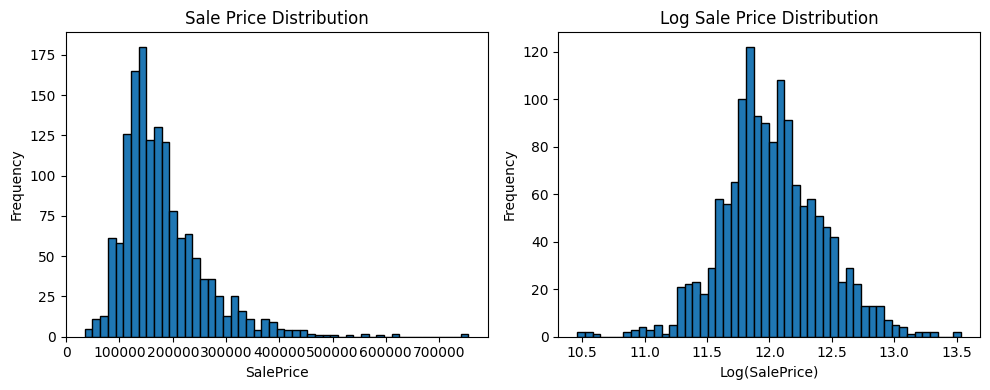

In [12]:
# Target variable distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y, bins=50, edgecolor='k')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Sale Price Distribution')

plt.subplot(1, 2, 2)
plt.hist(np.log(y), bins=50, edgecolor='k')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.title('Log Sale Price Distribution')
plt.tight_layout()
plt.show()


Applying a logarithmic transformation to the target variable makes the distribution more normal-like, which often improves model performance.

In [13]:
y = np.log(y)

XGBoost uses level-wise growth, building one complete level of the tree at a time. This creates balanced trees and makes it reliable for most situations. LightGBM uses leaf-wise growth, selecting the leaf that provides the best loss reduction at each split, which often leads to deeper trees and faster convergence on complex problems. CatBoost is specifically designed to handle categorical features natively without preprocessing, and features ordered boosting and symmetric trees to reduce overfitting risk — making it particularly effective for datasets with many categorical variables.

Each model mentioned above handles missing values natively. For categorical features, both LightGBM and CatBoost have mature native support, while XGBoost's categorical support is still experimental. Nonetheless, all three models can handle categorical features directly without the need for preprocessing. Therefore, we can feed data with missing values and categorical features directly into these models without needing imputation or encoding.

In [14]:
# Identify categorical columns in the dataset
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()

# Convert categorical columns: fill NaN with 'NaN' string for CatBoost, then to category dtype for XGBoost
for col in categorical_cols:
    X[col] = X[col].fillna('NaN')
    X[col] = X[col].astype('category')

In [15]:
# Common parameters for fair comparison across all three models
common_params = {
    'learning_rate': 0.1,
    'max_depth': 5,
    'random_state': 42,
}

In [16]:
# XGBoost model initialization 
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    **common_params,
    enable_categorical=True,
    verbosity=0,
)

# LightGBM model initialization
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    **common_params,
    num_leaves=2**common_params['max_depth'],  # based on documentation (and lecture) recommendation
    verbose=-1,
)

# CatBoost model initialization
cb_model = cb.CatBoostRegressor(
    iterations=100,
    **common_params,
    verbose=False,
    cat_features=categorical_cols,
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
times_xgb = []
times_lgb = []
times_cb = []

for _ in range(5):  # Run 5 times
    # XGBoost
    start = time.time()
    xgb_model.fit(X_train, y_train)
    times_xgb.append(time.time() - start)
    
    # LightGBM
    start = time.time()
    lgb_model.fit(X_train, y_train, categorical_feature=categorical_cols)
    times_lgb.append(time.time() - start)
    
    # CatBoost
    start = time.time()
    cb_model.fit(X_train, y_train)
    times_cb.append(time.time() - start)

# Print results
print(f"XGBoost: Mean: {np.mean(times_xgb):.4f}s, Std: {np.std(times_xgb):.4f}s")
print(f"LightGBM: Mean: {np.mean(times_lgb):.4f}s, Std: {np.std(times_lgb):.4f}s")
print(f"CatBoost: Mean: {np.mean(times_cb):.4f}s, Std: {np.std(times_cb):.4f}s")

XGBoost: Mean: 0.1648s, Std: 0.0163s
LightGBM: Mean: 0.1977s, Std: 0.0133s
CatBoost: Mean: 0.2226s, Std: 0.0272s


From docs: tracemalloc.get_traced_memory()
Get the current size and peak size of memory blocks traced by the tracemalloc module as a tuple

In [19]:
# XGBoost
tracemalloc.start()
xgb_model.fit(X_train, y_train)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"XGBoost memory usage: Current={current / (1024 * 1024):.2f} MB, Peak={peak / (1024 * 1024):.2f} MB")

# LightGBM
tracemalloc.start()
lgb_model.fit(X_train, y_train, categorical_feature=categorical_cols)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"LightGBM memory usage: Current={current / (1024 * 1024):.2f} MB, Peak={peak / (1024 * 1024):.2f} MB")

# CatBoost
tracemalloc.start()
cb_model.fit(X_train, y_train)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"CatBoost memory usage: Current={current / (1024 * 1024):.2f} MB, Peak={peak / (1024 * 1024):.2f} MB")


XGBoost memory usage: Current=0.06 MB, Peak=0.53 MB
LightGBM memory usage: Current=0.11 MB, Peak=1.42 MB
CatBoost memory usage: Current=0.02 MB, Peak=0.06 MB


For the investigated dataset, XGBoost and CatBoost turn out to be relatively fast, with comparable training times. In terms of memory usage, CatBoost was the most efficient, followed by XGBoost and then LightGBM. 

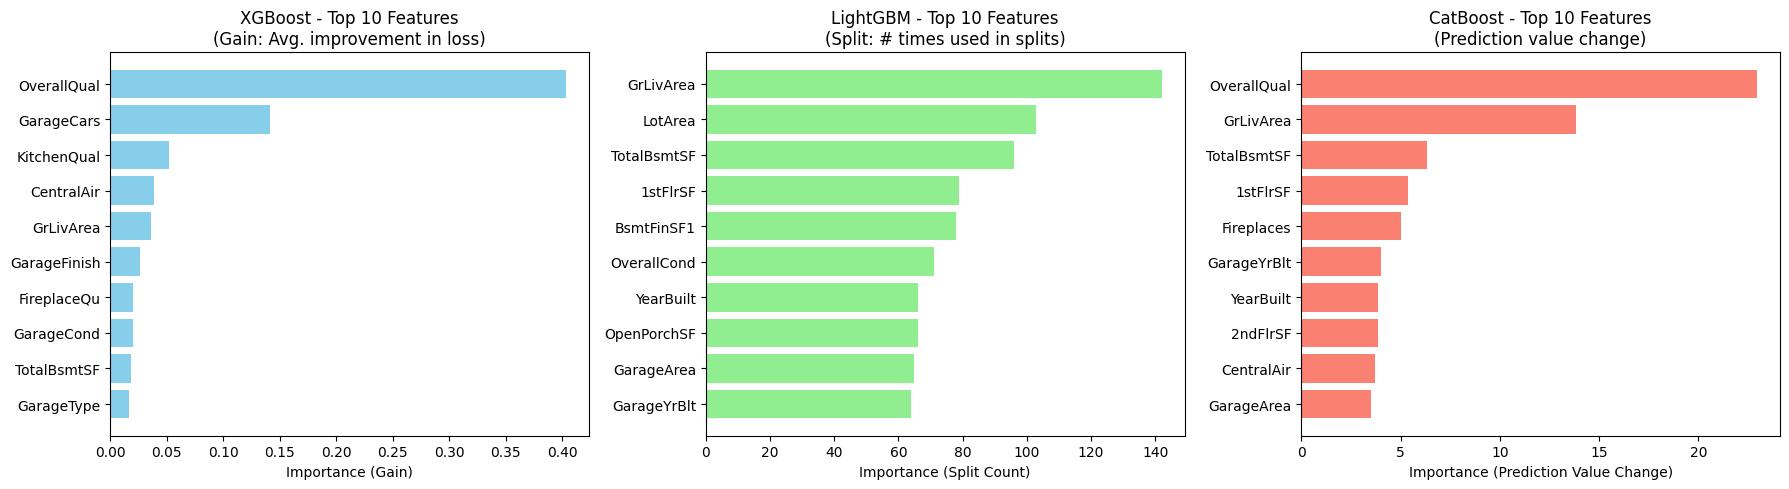

In [20]:
# get feature importance top 10 features for each model and plot them in a bar chart

# Extract feature importances for all three models
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

lgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

cb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

# Plot feature importances side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost (Gain-based importance)
# Gain-based importance measures the average improvement in loss when a feature is used in splits across all trees. It reflects how much a feature contributes to reducing the error of the model.
axes[0].barh(xgb_importance['feature'], xgb_importance['importance'], color='skyblue')
axes[0].set_xlabel('Importance (Gain)')
axes[0].set_title('XGBoost - Top 10 Features\n(Gain: Avg. improvement in loss)')
axes[0].invert_yaxis()

# LightGBM (Split-based importance)
# Split-based importance measures the number of times a feature is used in splits across all trees. It reflects how often a feature is utilized in the decision-making process.
axes[1].barh(lgb_importance['feature'], lgb_importance['importance'], color='lightgreen')
axes[1].set_xlabel('Importance (Split Count)')
axes[1].set_title('LightGBM - Top 10 Features\n(Split: # times used in splits)')
axes[1].invert_yaxis()

# CatBoost (Permutation-based importance)
# For each feature, PredictionValuesChange shows how much on average the prediction changes if the feature value changes.
axes[2].barh(cb_importance['feature'], cb_importance['importance'], color='salmon')
axes[2].set_xlabel('Importance (Prediction Value Change)')
axes[2].set_title('CatBoost - Top 10 Features\n(Prediction value change)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

On the plot, we can see that the features' importance differs among the models. However, features such as GrLivArea (Above grade (ground) living area square feet) and TotalBsmtSF (Total square feet of basement area), as well as those connected with the garage, play a vital role for each model.

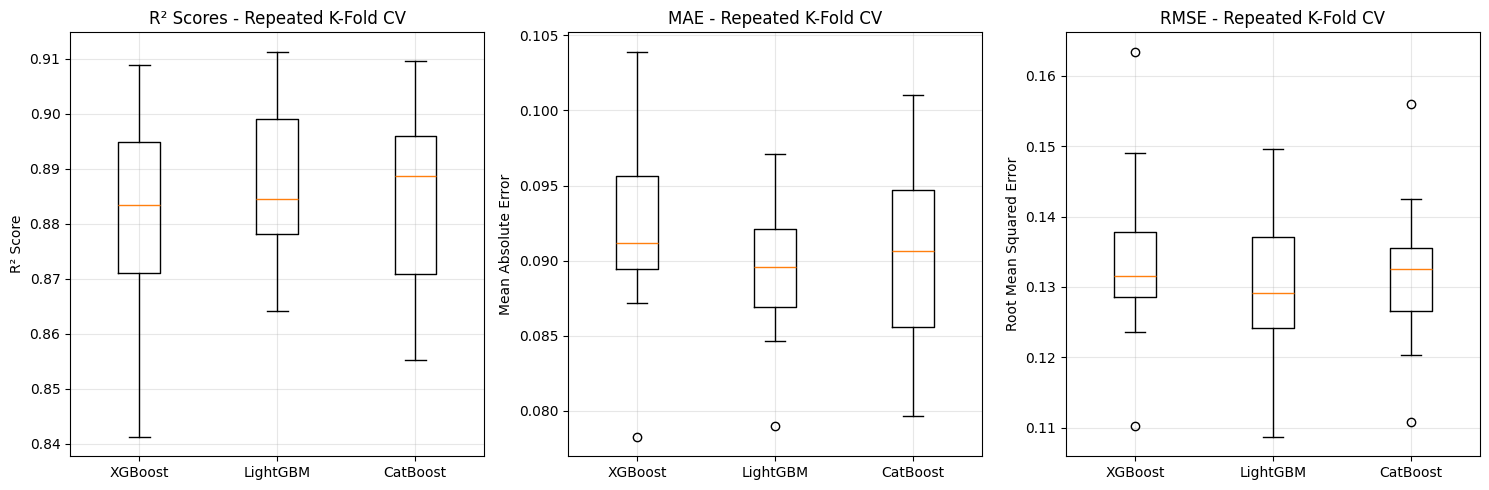

Repeated K-Fold Cross-Validation Results (5 folds, 3 repeats)

XGBoost:
  R² Score:  0.8812 ± 0.0180
  MAE:       0.0920 ± 0.0057
  RMSE:      0.1339 ± 0.0115

LightGBM:
  R² Score:  0.8881 ± 0.0152
  MAE:       0.0895 ± 0.0045
  RMSE:      0.1300 ± 0.0101

CatBoost:
  R² Score:  0.8848 ± 0.0159
  MAE:       0.0903 ± 0.0061
  RMSE:      0.1319 ± 0.0104


In [21]:
# Set up Repeated K-Fold (5 folds, 3 repeats)
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# Store results for each model
results = {
    'XGBoost': {'R2': [], 'MAE': [], 'RMSE': []},
    'LightGBM': {'R2': [], 'MAE': [], 'RMSE': []},
    'CatBoost': {'R2': [], 'MAE': [], 'RMSE': []}
}

# Perform repeated k-fold cross validation
for train_idx, test_idx in rkf.split(X_train):
    X_fold_train, X_fold_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_fold_train, y_fold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]
    
    # XGBoost
    xgb_cv = xgb.XGBRegressor(**common_params, n_estimators=100, enable_categorical=True, verbosity=0)
    xgb_cv.fit(X_fold_train, y_fold_train)
    y_pred_xgb = xgb_cv.predict(X_fold_test)
    results['XGBoost']['R2'].append(r2_score(y_fold_test, y_pred_xgb))
    results['XGBoost']['MAE'].append(mean_absolute_error(y_fold_test, y_pred_xgb))
    results['XGBoost']['RMSE'].append(np.sqrt(mean_squared_error(y_fold_test, y_pred_xgb)))
    
    # LightGBM
    lgb_cv = lgb.LGBMRegressor(**common_params, n_estimators=100, num_leaves=2**common_params['max_depth'], verbose=-1)
    lgb_cv.fit(X_fold_train, y_fold_train, categorical_feature=categorical_cols)
    y_pred_lgb = lgb_cv.predict(X_fold_test)
    results['LightGBM']['R2'].append(r2_score(y_fold_test, y_pred_lgb))
    results['LightGBM']['MAE'].append(mean_absolute_error(y_fold_test, y_pred_lgb))
    results['LightGBM']['RMSE'].append(np.sqrt(mean_squared_error(y_fold_test, y_pred_lgb)))
    
    # CatBoost
    cb_cv = cb.CatBoostRegressor(**common_params, iterations=100, verbose=False, cat_features=categorical_cols)
    cb_cv.fit(X_fold_train, y_fold_train)
    y_pred_cb = cb_cv.predict(X_fold_test)
    results['CatBoost']['R2'].append(r2_score(y_fold_test, y_pred_cb))
    results['CatBoost']['MAE'].append(mean_absolute_error(y_fold_test, y_pred_cb))
    results['CatBoost']['RMSE'].append(np.sqrt(mean_squared_error(y_fold_test, y_pred_cb)))

# Create box plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² scores
ax = axes[0]
ax.boxplot([results['XGBoost']['R2'], results['LightGBM']['R2'], results['CatBoost']['R2']])
ax.set_xticklabels(['XGBoost', 'LightGBM', 'CatBoost'])
ax.set_ylabel('R² Score')
ax.set_title('R² Scores - Repeated K-Fold CV')
ax.grid(True, alpha=0.3)

# MAE
ax = axes[1]
ax.boxplot([results['XGBoost']['MAE'], results['LightGBM']['MAE'], results['CatBoost']['MAE']])
ax.set_xticklabels(['XGBoost', 'LightGBM', 'CatBoost'])
ax.set_ylabel('Mean Absolute Error')
ax.set_title('MAE - Repeated K-Fold CV')
ax.grid(True, alpha=0.3)

# RMSE
ax = axes[2]
ax.boxplot([results['XGBoost']['RMSE'], results['LightGBM']['RMSE'], results['CatBoost']['RMSE']])
ax.set_xticklabels(['XGBoost', 'LightGBM', 'CatBoost'])
ax.set_ylabel('Root Mean Squared Error')
ax.set_title('RMSE - Repeated K-Fold CV')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Repeated K-Fold Cross-Validation Results (5 folds, 3 repeats)")
print("=" * 70)
for model in results:
    print(f"\n{model}:")
    print(f"  R² Score:  {np.mean(results[model]['R2']):.4f} ± {np.std(results[model]['R2']):.4f}")
    print(f"  MAE:       {np.mean(results[model]['MAE']):.4f} ± {np.std(results[model]['MAE']):.4f}")
    print(f"  RMSE:      {np.mean(results[model]['RMSE']):.4f} ± {np.std(results[model]['RMSE']):.4f}")

All three models show similar performance in the repeated k-fold cross-validation. This suggests they handle the house prices prediction task equally well with the current hyperparameters. Further improvement could be achieved through more careful hyperparameter tuning and feature engineering.

## Problem 1.3: Stacked Ensemble (25 points)
Build a two-level stacked ensemble:

• Level 0: Random Forest, XGBoost, Neural Network.

• Level 1: Ridge Regression meta-learner.

• Use cross-validation to generate out-of-fold predictions.

• Compare with individual base models.

XGBoost and Random Forest are tree-based models that can capture complex interactions between features, while the Neural Network can model non-linear relationships. The Ridge Regression meta-learner will combine the predictions from these base models to potentially improve overall performance by leveraging their complementary strengths.

In [22]:
from sklearn.model_selection import train_test_split # For splitting the dataset into training and testing sets
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # For evaluating model performance
from sklearn.ensemble import RandomForestRegressor # For Random Forest implementation
import xgboost as xgb  # for XGBoost implementation
from sklearn.neural_network import MLPRegressor  # For neural network regression implementation
from sklearn.preprocessing import StandardScaler  # For feature scaling before training the neural network
from sklearn.model_selection import KFold # For performing repeated K-Fold cross-validation
from sklearn.linear_model import Ridge # For Ridge regression as a meta-learner in stacking
from warnings import filterwarnings
filterwarnings("ignore")  # Suppress warnings for cleaner output

In [23]:
# Fetch the California housing dataset, same as Problem 1.1
data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_scalers = []
y_scalers = []

# K-fold loop
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold splits on the training set for out-of-fold predictions

out_of_fold_predictions = np.zeros((y_train.shape[0], 3))  # To store predictions for each of the 3 models (RF, XGB, NN)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_train)):
    X_fold_train, X_fold_test = X_train[train_idx], X_train[test_idx]
    y_fold_train, y_fold_test = y_train[train_idx], y_train[test_idx]

    # Train and evaluate Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_fold_train, y_fold_train)
    y_pred_rf = rf.predict(X_fold_test)
    out_of_fold_predictions[test_idx, 0] = y_pred_rf
    print(f"Fold {fold + 1} - Random Forest R²: {r2_score(y_fold_test, y_pred_rf):.4f}, MAE: {mean_absolute_error(y_fold_test, y_pred_rf):.4f}, RMSE: {np.sqrt(mean_squared_error(y_fold_test, y_pred_rf)):.4f}")

    # Train and evaluate XGBoost
    xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)
    xgb_model.fit(X_fold_train, y_fold_train)
    y_pred_xgb = xgb_model.predict(X_fold_test)
    out_of_fold_predictions[test_idx, 1] = y_pred_xgb
    print(f"Fold {fold + 1} - XGBoost R²: {r2_score(y_fold_test, y_pred_xgb):.4f}, MAE: {mean_absolute_error(y_fold_test, y_pred_xgb):.4f}, RMSE: {np.sqrt(mean_squared_error(y_fold_test, y_pred_xgb)):.4f}")

    # Standardize features for neural network
    X_scaler = StandardScaler()
    X_fold_train_scaled = X_scaler.fit_transform(X_fold_train)
    X_fold_test_scaled = X_scaler.transform(X_fold_test)
    X_scalers.append(X_scaler)

    # Standardize target for neural network
    y_scaler = StandardScaler()
    y_fold_train_scaled = y_scaler.fit_transform(y_fold_train.reshape(-1, 1)).ravel()
    y_fold_test_scaled = y_scaler.transform(y_fold_test.reshape(-1, 1)).ravel()
    y_scalers.append(y_scaler)

    # Train and evaluate Neural Network
    nn_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=100, random_state=42)
    nn_model.fit(X_fold_train_scaled, y_fold_train_scaled)  
    y_pred_nn_scaled = nn_model.predict(X_fold_test_scaled)
    y_pred_nn = y_scalers[fold].inverse_transform(y_pred_nn_scaled.reshape(-1, 1)).ravel()
    out_of_fold_predictions[test_idx, 2] = y_pred_nn
    print(f"Fold {fold + 1} - Neural Network R²: {r2_score(y_fold_test, y_pred_nn):.4f}, MAE: {mean_absolute_error(y_fold_test, y_pred_nn):.4f}, RMSE: {np.sqrt(mean_squared_error(y_fold_test, y_pred_nn)):.4f}")
    print("-" * 50)
    
print()

# Train Ridge regression on out-of-fold predictions i.e. on the entire training set
ridge_meta = Ridge(alpha=1.0, random_state=42)
ridge_meta.fit(out_of_fold_predictions, y_train)

# Train individual models on the entire training set
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)
y_pred_rf_final = rf_final.predict(X_test)
print(f"Final Random Forest R²: {r2_score(y_test, y_pred_rf_final):.4f}, MAE: {mean_absolute_error(y_test, y_pred_rf_final):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_final)):.4f}")

xgb_final = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)
xgb_final.fit(X_train, y_train)
y_pred_xgb_final = xgb_final.predict(X_test)
print(f"Final XGBoost R²: {r2_score(y_test, y_pred_xgb_final):.4f}, MAE: {mean_absolute_error(y_test, y_pred_xgb_final):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_final)):.4f}")

# scaling features and target for neural network
X_scaler_final = StandardScaler()
X_train_scaled = X_scaler_final.fit_transform(X_train)
X_test_scaled = X_scaler_final.transform(X_test)
y_scaler_final = StandardScaler()
y_train_scaled = y_scaler_final.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler_final.transform(y_test.reshape(-1, 1)).ravel()

# fit NN
nn_final = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=100, random_state=42)
nn_final.fit(X_train_scaled, y_train_scaled)
y_pred_nn_final_scaled = nn_final.predict(X_test_scaled)
y_pred_nn_final = y_scaler_final.inverse_transform(y_pred_nn_final_scaled.reshape(-1, 1)).ravel()
print(f"Final Neural Network R²: {r2_score(y_test, y_pred_nn_final):.4f}, MAE: {mean_absolute_error(y_test, y_pred_nn_final):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_nn_final)):.4f}")

# Get predictions from each base model on the test set
base_predictions_test = np.column_stack((y_pred_rf_final, y_pred_xgb_final, y_pred_nn_final))
# Get final predictions from Ridge meta-learner
final_predictions = ridge_meta.predict(base_predictions_test)

# Evaluate the stacked ensemble on the test set
print(f"\nStacked Ensemble R²: {r2_score(y_test, final_predictions):.4f}, MAE: {mean_absolute_error(y_test, final_predictions):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, final_predictions)):.4f}")

# check Ridge coefficients to see which base model is contributing more to the final prediction
print("\nRidge Regression Coefficients (Meta-learner):")
print(f"Random Forest Coefficient: {ridge_meta.coef_[0]:.4f}")
print(f"XGBoost Coefficient: {ridge_meta.coef_[1]:.4f}")
print(f"Neural Network Coefficient: {ridge_meta.coef_[2]:.4f}")

Fold 1 - Random Forest R²: 0.7998, MAE: 0.3440, RMSE: 0.5256
Fold 1 - XGBoost R²: 0.8193, MAE: 0.3396, RMSE: 0.4993
Fold 1 - Neural Network R²: 0.7853, MAE: 0.3774, RMSE: 0.5443
--------------------------------------------------
Fold 2 - Random Forest R²: 0.8128, MAE: 0.3295, RMSE: 0.4987
Fold 2 - XGBoost R²: 0.8260, MAE: 0.3273, RMSE: 0.4808
Fold 2 - Neural Network R²: 0.7851, MAE: 0.3579, RMSE: 0.5342
--------------------------------------------------
Fold 3 - Random Forest R²: 0.8086, MAE: 0.3314, RMSE: 0.5052
Fold 3 - XGBoost R²: 0.8277, MAE: 0.3248, RMSE: 0.4793
Fold 3 - Neural Network R²: 0.8019, MAE: 0.3444, RMSE: 0.5139
--------------------------------------------------
Fold 4 - Random Forest R²: 0.7964, MAE: 0.3367, RMSE: 0.5237
Fold 4 - XGBoost R²: 0.8174, MAE: 0.3274, RMSE: 0.4960
Fold 4 - Neural Network R²: 0.7827, MAE: 0.3679, RMSE: 0.5410
--------------------------------------------------
Fold 5 - Random Forest R²: 0.8061, MAE: 0.3317, RMSE: 0.5008
Fold 5 - XGBoost R²: 0.

For the train set, XGBoost consecutively outperforms the other two base models both in terms of R2 score and error metrics MAE and RMSE across all folds. The Random Forest model performs slightly better than the Neural Network, which may be due to the fact that tree-based models are often more effective for tabular data like the California housing dataset. 

When evaluating for the test set, we observe a similar pattern where XGBoost continues to outperform the other two base models. The Random Forest model still performs better than the Neural Network. Therefore, it makes sense that the ensemble weighs XGBoost's influence more heavily. Weights of the other two base models are similar at around 0.2, while XGBoost's weight is around 0.6. The stacked ensemble model, which combines the predictions of all three base models using Ridge Regression, is able to outperform all three base models in terms of R2 score, MAE, and RMSE. This indicates that the meta-learner is effectively leveraging the complementary strengths of the base models to improve overall performance on the test set. 

## Problem 1.4: Bayesian Optimization with Optuna (20 points)
Use Optuna to optimize XGBoost hyperparameters:

• Optimize at least 6 hyperparameters (learning rate, max depth, subsample, etc.).

• Run 100 trials and visualize optimization history.

• Compare with random search (same number of trials).

• Analyze hyperparameter importance.

In [24]:
import optuna  # For hyperparameter optimization
from sklearn.model_selection import cross_val_score, KFold # For performing cross-validation during hyperparameter tuning

In [25]:
data = pd.read_csv('data/house_prices.csv', index_col=0)
X, y = data.drop(columns="SalePrice"), data["SalePrice"]
y = np.log(y)
# Identify categorical columns in the dataset
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()

# Convert categorical columns: fill NaN with 'NaN' string for CatBoost, then to category dtype for XGBoost
for col in categorical_cols:
    X[col] = X[col].fillna('NaN')
    X[col] = X[col].astype('category')

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [27]:
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10)
    }
    
    model = xgb.XGBRegressor(**param_grid, random_state=42, verbosity=0, enable_categorical=True)
    return np.mean(cross_val_score(model, X_train, y_train, cv=kf, scoring='r2'))  # Use R² as the evaluation metric

In [28]:
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress Optuna logs for cleaner output
opt_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))  
random_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=42))
opt_study.optimize(objective, n_trials=100)
random_study.optimize(objective, n_trials=100)

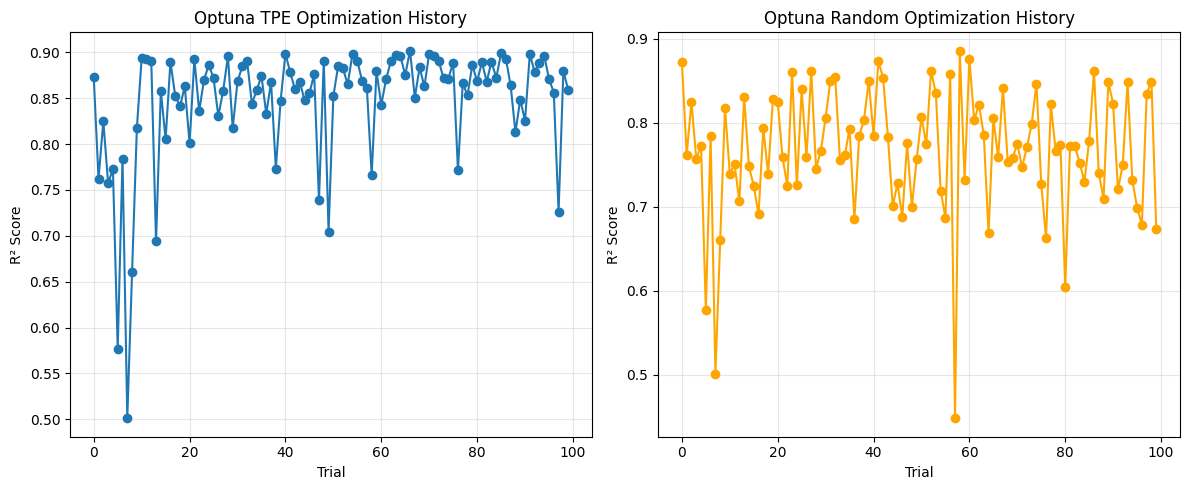

In [29]:
# visualize optimization history
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(opt_study.trials_dataframe()['value'], marker='o')
axes[0].set_title('Optuna TPE Optimization History')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('R² Score')
axes[0].grid(True, alpha=0.3)

axes[1].plot(random_study.trials_dataframe()['value'], marker='o', color='orange')
axes[1].set_title('Optuna Random Optimization History')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('R² Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TPE consistently achieves higher and less volatile R² scores compared to random search, making it a more reliable choice for hyperparameter optimization.

In [30]:
# hyperparameter importance for TPE study
fig_tpe = optuna.visualization.plot_param_importances(opt_study)
fig_tpe.update_layout(title="Hyperparameter Importance (TPE)")
fig_tpe.show()

# hyperparameter importance for Random study
fig_random = optuna.visualization.plot_param_importances(random_study)
fig_random.update_layout(title="Hyperparameter Importance (Random)")
fig_random.show()


The hyperparameter importance rankings are similar across both studies, with gamma, learning_rate, and subsample identified as the most influential parameters. However, random search emphasizes learning_rate more strongly than subsample, whereas TPE assigns nearly equal importance to both.

In [31]:
# predictive performance on test using both sets of best hyperparameters
best_xgb_tpe = xgb.XGBRegressor(**opt_study.best_params, random_state=42, verbosity=0, enable_categorical=True)
best_xgb_random = xgb.XGBRegressor(**random_study.best_params, random_state=42, verbosity=0, enable_categorical=True)
best_xgb_tpe.fit(X_train, y_train)
best_xgb_random.fit(X_train, y_train)
y_pred_tpe = best_xgb_tpe.predict(X_test)
y_pred_random = best_xgb_random.predict(X_test)

print(f"Test R² Score (TPE): {r2_score(y_test, y_pred_tpe):.4f}, MAE: {mean_absolute_error(y_test, y_pred_tpe):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tpe)):.4f}")
print(f"Test R² Score (Random): {r2_score(y_test, y_pred_random):.4f}, MAE: {mean_absolute_error(y_test, y_pred_random):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_random)):.4f}")


Test R² Score (TPE): 0.9030, MAE: 0.0837, RMSE: 0.1345
Test R² Score (Random): 0.8966, MAE: 0.0903, RMSE: 0.1389


Metrics for TPE-optimized model are better with R² being higher and MAE/RMSE being lower compared to the Random-optimized model, indicating that the TPE optimization found a better set of hyperparameters for the XGBoost model on this dataset. 

In [32]:
# Print best hyperparameters and scores for both studies
print("="*50)
print("Best Hyperparameters (TPE):")
for param, value in opt_study.best_params.items():
    print(f"  {param}: {value}")
print("Best R² Score (TPE):", opt_study.best_value)
print("="*50)
print("Best Hyperparameters (Random):")
for param, value in random_study.best_params.items():
    print(f"  {param}: {value}")
print("Best R² Score (Random):", random_study.best_value)


Best Hyperparameters (TPE):
  n_estimators: 188
  max_depth: 9
  learning_rate: 0.037906626295432864
  subsample: 0.6122247348099533
  colsample_bytree: 0.5211236410368423
  lambda: 0.15991017720318934
  gamma: 0.007978486540842752
  min_child_weight: 9
Best R² Score (TPE): 0.9017429763740619
Best Hyperparameters (Random):
  n_estimators: 195
  max_depth: 5
  learning_rate: 0.026425997853498483
  subsample: 0.9342995640947301
  colsample_bytree: 0.6117979192597263
  lambda: 7.126727573532308
  gamma: 0.06077237344908171
  min_child_weight: 10
Best R² Score (Random): 0.8859822018386124
